<a href="https://colab.research.google.com/github/lirazshimon11/Data-Science-Course---Assignments/blob/main/%D7%A2%D7%91%D7%95%D7%93%D7%AA_%D7%91%D7%99%D7%AA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

שם סטודנט: לירז שמעון
ת.ז: 326720505

In [108]:
!kaggle datasets download mohitkumar282/used-car-dataset
!unzip used-car-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/mohitkumar282/used-car-dataset
License(s): CC0-1.0
used-car-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  used-car-dataset.zip
replace used_car_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: used_car_dataset.csv    
  inflating: used_cars_dataset_v2.csv  


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc
from scipy.stats import skew, kurtosis
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [110]:
df = pd.read_csv("used_cars_dataset_v2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         14993 non-null  object
 1   model         14993 non-null  object
 2   Year          14993 non-null  int64 
 3   Age           14993 non-null  int64 
 4   kmDriven      14905 non-null  object
 5   Transmission  14993 non-null  object
 6   Owner         14993 non-null  object
 7   FuelType      14993 non-null  object
 8   PostedDate    14993 non-null  object
 9   AdditionInfo  14993 non-null  object
 10  AskPrice      14993 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


In [111]:
print(df.shape)
df.describe().T

(14993, 11)


,count,mean,std,min,25%,50%,75%,max
Year,"14,993.00","2,016.32",4.34,"1,900.00","2,014.00","2,017.00","2,019.00","2,024.00"
Age,"14,993.00",7.68,4.34,0.00,5.00,7.00,10.00,124.00


In [112]:
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


## Data Preprocessing and Feature Engineering

Before applying any machine learning algorithms, a comprehensive data preprocessing pipeline will be implemented to transform the raw dataset into a mathematically viable format. The models require strictly numerical inputs, meaning all text-based, categorical, and poorly formatted continuous features **must be cleaned and encoded**.

The preprocessing pipeline **will consist** of the following systematic steps:

1. **Handling Missing Values:** Rows containing null values in critical columns (specifically `kmDriven`) **will be dropped** to ensure data integrity.
2. **Cleaning Continuous Variables:** - `AskPrice`: **Will be stripped** of non-numeric characters (like currency symbols and commas), converted to float, and multiplied by a conversion rate (0.012) to translate Indian Rupees (INR - ₹) to USD for more interpretable evaluation metrics.
   - `kmDriven`: The "km" string and commas **will be removed**, and the values **will be converted** into pure integers.
3. **Ordinal Encoding:** The `Owner` column, which indicates the number of previous owners as text (e.g., "First", "Second"), **will be parsed and converted** into ordinal integers (1, 2, 3...). "Test Drive Cars" **will be mapped** to 0, and extreme outliers **will be capped** at 4 to prevent skewing the regression weights.
4. **One-Hot Encoding (Categorical Variables):** Preliminary testing revealed that an alternative technique (Label Encoding) falsely introduced ordinal relationships among the `Brand` categories (implying one brand is mathematically "greater" than another). This severely degraded the model's predictive accuracy, making its performance approximately 3 times worse. Consequently, One-Hot Encoding **will be applied** as the optimal method for both nominal variables (`Brand` and `Transmission`). To avoid the dummy variable trap (perfect multicollinearity), one reference category **will be systematically dropped**, generating pure binary (0 and 1) indicator columns.

The consolidated code block below executes this entire pipeline:

In [113]:
# =========================================================
# DATA PREPROCESSING & CLEANING PIPELINE
# =========================================================

# ---------------------------------------------------------
# STEP 1: Handle Missing Values
# Objective: Remove rows with missing data in critical columns.
# ---------------------------------------------------------
df = df.dropna(subset=['kmDriven'])
print("✅ Step 1: Missing values handled.")


# ---------------------------------------------------------
# STEP 2: Clean 'AskPrice' (Target Variable)
# Objective: Remove symbols (₹, commas), convert to numeric,
# and translate from Indian Rupees to USD for readability.
# ---------------------------------------------------------
if df['AskPrice'].dtype == 'object':
    df['AskPrice'] = df['AskPrice'].replace(r'[^\d.]', '', regex=True)
    df['AskPrice'] = pd.to_numeric(df['AskPrice'])
    df['AskPrice'] = df['AskPrice'] * 0.012  # Convert Rupees to Dollars
    print("✅ Step 2: 'AskPrice' converted to numeric (USD).")
else:
    print("⏩ Step 2: 'AskPrice' was already converted. Skipping.")


# ---------------------------------------------------------
# STEP 3: Clean 'kmDriven' (Mileage Feature)
# Objective: Remove the 'km' string and commas, then
# convert the column to pure integers.
# ---------------------------------------------------------
df['kmDriven'] = (
    df['kmDriven']
    .astype(str)
    .str.replace('km', '', case=False)
    .str.replace(',', '')
    .str.strip()
)
# Convert to float first to handle decimals safely, then to int
df['kmDriven'] = df['kmDriven'].astype(float).astype(int)
print("✅ Step 3: 'kmDriven' cleaned and converted to integer.")


# ---------------------------------------------------------
# STEP 4: Parse 'Owner' (Ordinal Feature)
# Objective: Convert text descriptions ("First", "Second")
# into ordinal numbers (1, 2, 3...) to represent depreciation.
# ---------------------------------------------------------
def parse_owner(text):
    if pd.isna(text): return None
    text = str(text).lower()

    if 'first' in text or '1' in text: return 1
    elif 'second' in text or '2' in text: return 2
    elif 'third' in text or '3' in text: return 3
    elif 'fourth' in text or '4' in text: return 4
    elif 'test' in text: return 0  # Dealership test drives
    else: return 4  # Cap extreme outliers at 4 to prevent skewing

df['Owner'] = df['Owner'].apply(parse_owner)
print("✅ Step 4: 'Owner' column parsed to ordinal integers.")


# ---------------------------------------------------------
# STEP 5: Encode 'Brand' & 'Transmission' (Categorical Features)
# Objective: Convert text categories into binary numbers (0 and 1)
# using One-Hot Encoding (Dummy Variables).
# ---------------------------------------------------------
cols_to_encode = ['Brand', 'Transmission']

# drop_first=True prevents the dummy variable trap
dummies = pd.get_dummies(df[cols_to_encode], drop_first=True, dtype=int)

# Robustness check: Drop existing dummy columns if cell is run multiple times
existing_dummy_cols = [col for col in dummies.columns if col in df.columns]
df = df.drop(columns=existing_dummy_cols)

# Concatenate the new integer dummy columns to the main dataframe
df = pd.concat([df, dummies], axis=1)
print("✅ Step 5: Categorical variables ('Brand', 'Transmission') encoded successfully.")


# =========================================================
# FINAL VERIFICATION
# =========================================================
print(f"\nFinal Dataset Shape after preprocessing: {df.shape}")
display(df.head())

✅ Step 1: Missing values handled.
✅ Step 2: 'AskPrice' converted to numeric (USD).
✅ Step 3: 'kmDriven' cleaned and converted to integer.
✅ Step 4: 'Owner' column parsed to ordinal integers.
✅ Step 5: Categorical variables ('Brand', 'Transmission') encoded successfully.

Final Dataset Shape after preprocessing: (14905, 53)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,...,Brand_Renault,Brand_Rolls-Royce,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Volkswagen,Brand_Volvo,Transmission_Manual
0,Honda,City,2001,23,98000,Manual,2,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",...,0,0,0,0,0,0,0,0,0,1
1,Toyota,Innova,2009,15,190000,Manual,2,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",...,0,0,0,0,0,1,0,0,0,1
2,Volkswagen,VentoTest,2010,14,77246,Manual,1,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",...,0,0,0,0,0,0,0,1,0,1
3,Maruti Suzuki,Swift,2017,7,83500,Manual,2,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,...,0,0,0,0,0,0,0,0,0,1
4,Maruti Suzuki,Baleno,2019,5,45000,Automatic,1,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",...,0,0,0,0,0,0,0,0,0,0


## Feature Selection and Matrix Initialization

Following data preprocessing, we isolate the final numerical features (`Age`, `kmDriven`, encoded `Owner`) and the target (`AskPrice`). We dynamically append all generated One-Hot dummy variables (`Brand`, `Transmission`). Using `.copy()`, an independent dataframe (`df_model`) is created to ensure a strictly numeric, clean input space for the machine learning models while leaving the original dataset intact.

In [114]:
# 1. Define the core numerical columns and the target variable
core_cols = ['Age', 'kmDriven', 'Owner', 'AskPrice']

# 2. Dynamically identify all dummy columns generated for Brand and Transmission
# This automatically grabs columns like 'Brand_Toyota', 'Transmission_Manual', etc.
dummy_cols = [col for col in df.columns if col.startswith('Brand_') or col.startswith('Transmission_')]

# 3. Combine the core columns and dummy columns to form the final feature list
final_features = core_cols + dummy_cols

# 4. Create an independent, clean dataframe specifically for modeling
df_model = df[final_features].copy()

# 5. Verify the structure and contents of the final modeling dataframe
print(f"Final modeling dataset shape: {df_model.shape}")
display(df_model.head(10))
df_model.shape

Final modeling dataset shape: (14905, 46)


,Age,kmDriven,Owner,AskPrice,Brand_Ashok,Brand_Aston Martin,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,...,Brand_Renault,Brand_Rolls-Royce,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Volkswagen,Brand_Volvo,Transmission_Manual
0,23,98000,2,"2,340.00",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,15,190000,2,"4,500.00",0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,14,77246,1,"2,219.99",0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,7,83500,2,"6,780.00",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,45000,1,"8,220.00",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,10,83000,1,"16,200.00",0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,10,168000,2,"12,300.00",0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
7,5,25000,2,"71,400.00",0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,33759,2,"7,464.00",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,7,69713,2,"7,788.00",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


(14905, 46)

### Great, now the DataFrame is ready for model use!

With the successful execution of the data preprocessing and feature engineering pipeline, our dataset (`df_model`) is now a strictly numerical matrix. We are officially transitioning from data preparation to the core predictive modeling and error analysis phase.

As mandated by the assignment, we will establish a **Linear Regression** model to serve as our performance baseline. To ensure our evaluation is rigorous, unbiased, and free from data leakage, we will implement **k-fold cross-validation**.

**I select k=5** to balance computational efficiency with a robust training set size (approximately 80% of the data per fold).

Predictions calculated cleanly without data leakage!

🚨 TOP 5 WORST PREDICTIONS (Largest Errors):


,Brand,Age,kmDriven,Owner,PredictedPrice_LR,AskPrice,Residual_LR
3331,Rolls-Royce,9,11500,2,"9,120.51","510,000.00","500,879.49"
12685,Lamborghini,3,26000,2,"15,302.80","468,000.00","452,697.20"
13286,Mercedes-Benz,1,6000,1,"50,089.26","417,600.00","367,510.74"
10291,Mercedes-Benz,0,3500,1,"50,427.78","366,000.00","315,572.22"
331,Aston Martin,8,25700,1,"11,443.51","316,800.00","305,356.49"


------------------------------------------------------------


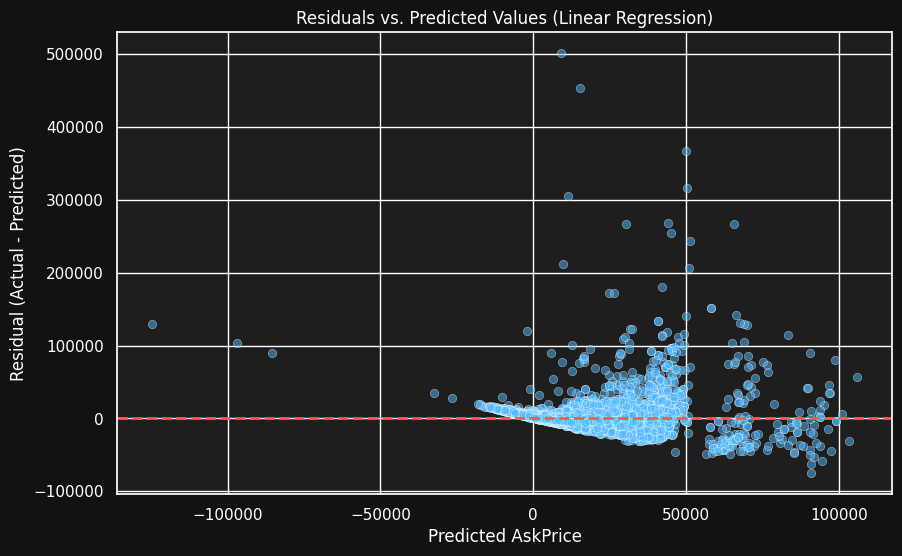

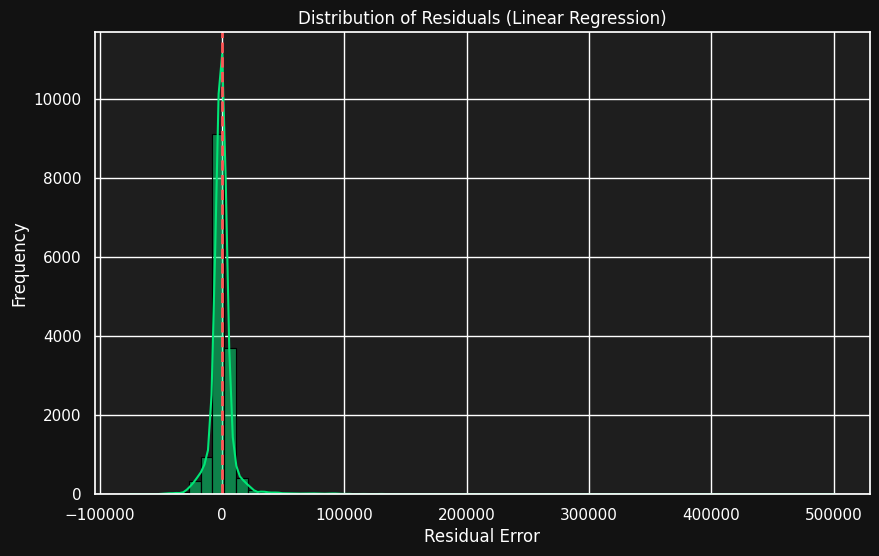

In [115]:
# =============================================
# ============ Q 1.1 - Linear Regression ============
# =============================================


# ---------------- Q 1.1 - plot 1 - Linear Regression ----------------

# Clean X from ANY previous predictions to prevent data leakage
cols_to_drop = ['AskPrice', 'PredictedPrice_LR', 'Residual_LR', 'PredictedPrice', 'Residual', 'Abs_Residual_LR']
X = df_model.drop(columns=cols_to_drop, errors='ignore') # drop the old columns
y = df_model['AskPrice'] # set the target

# Train and predict using k-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()
predictions = cross_val_predict(lr_model, X, y, cv=kf)

# Explicitly add the fresh predictions to the dataframe
df_model['PredictedPrice_LR'] = predictions
df_model['Residual_LR'] = df_model['AskPrice'] - df_model['PredictedPrice_LR'] # calculate the error

print("Predictions calculated cleanly without data leakage!\n")

# ==========================================
# DIAGNOSTIC PRINTS: Hunt down the outliers with their Brands
# ==========================================
df_model['Abs_Residual_LR'] = df_model['Residual_LR'].abs() # get absolute error

# Sort by the biggest errors and pull the top 5
worst_cases = df_model.sort_values(by='Abs_Residual_LR', ascending=False).head(5).copy()
worst_cases['Brand'] = df.loc[worst_cases.index, 'Brand'] # pull the original text brand from the main df

print("🚨 TOP 5 WORST PREDICTIONS (Largest Errors):")
cols_to_show = ['Brand', 'Age', 'kmDriven', 'Owner', 'PredictedPrice_LR', 'AskPrice', 'Residual_LR']
display(worst_cases[cols_to_show]) # display the worst ones
print("-" * 60)

# ==========================================
# Plot residuals as a function of predicted values
# ==========================================
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212"})

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_model['PredictedPrice_LR'], y=df_model['Residual_LR'], alpha=0.5, color='#4db8ff')
plt.axhline(y=0, color='#ff5555', linestyle='--', linewidth=2) # red reference line at zero

plt.title('Residuals vs. Predicted Values (Linear Regression)', color='white')
plt.xlabel('Predicted AskPrice', color='white')
plt.ylabel('Residual (Actual - Predicted)', color='white')
plt.tick_params(colors='white', which='both') # force the ticks to be white

plt.show()


# ---------------- Q 1.1 - plot 2 - Linear Regression ----------------

# Plot the distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(df_model['Residual_LR'], bins=60, kde=True, color='#00e676', edgecolor='black')
plt.axvline(x=0, color='#ff5555', linestyle='--', linewidth=2) # add a vertical red reference line at zero

plt.title('Distribution of Residuals (Linear Regression)', color='white')
plt.xlabel('Residual Error', color='white')
plt.ylabel('Frequency', color='white')
plt.tick_params(colors='white', which='both') # make the numbers white here too

plt.show()

## 1.1 Residual Analysis

To diagnose the baseline Linear Regression model, I visualized the residuals (the difference between the actual and predicted prices) using two key plots, alongside a diagnostic print of the top 5 largest errors.

### 1. Residuals vs. Predicted Values (Scatter Plot)
I generated a scatter plot to examine the relationship between the model's predictions and its errors.

* **Observation:** The plot reveals a distinct "funnel" shape, widening significantly as the predicted asking price increases. Furthermore, my diagnostic prints revealed that the absolute worst predictions were exclusively ultra-luxury and exotic brands (e.g., Rolls-Royce, Lamborghini, and Aston Martin), with the highest residual reaching a massive \$500,879.
* **Interpretation:** This demonstrates that while my linear model is precise for low-budget vehicles, its error margin expands drastically for high-value vehicles. The model's rigid linear assumptions completely failed to capture the complex pricing dynamics of these premium cars, attempting to price a 9-year-old Rolls-Royce like a standard commuter car at roughly \$9,120.

### 2. Distribution of Residuals (Histogram)
Following the scatter plot, I examined the distribution of the residuals using a histogram overlaid with a Kernel Density Estimate (KDE).

* **Observation:** While the central spike of the distribution is tight, it exhibits a severely right-skewed tail stretching all the way to \$500,000.
* **Interpretation:** This heavy right tail represents those extreme positive residuals where the actual price is vastly higher than the predicted price, proving that the model systematically under-predicts the value of specific outliers.

### Model Evaluation:
Based on the visual analysis, I can address the fundamental questions regarding the model's reliability:

* **Are the residuals centered around zero?**
  Yes, but only partially. While the vast majority of residuals (representing standard, average-priced cars) are tightly centered around zero, the overall distribution is severely distorted by extreme positive outliers.
* **Do the residuals exhibit any systematic patterns?**
  Yes. The model systematically under-predicts the value of specific outliers, primarily luxury and exotic vehicles, creating a heavy right-skewed tail in the distribution rather than random, balanced errors.
* **Is there evidence of heteroscedasticity (i.e., non-constant variance)?**
  Yes, there is clear evidence of heteroscedasticity. The scatter plot displays a classic "funnel" pattern, where the variance (spread) of the residuals increases drastically as the predicted asking price increases.

**Conclusion:** The linear regression model is fundamentally too simple for this dataset. It suffers from **underfitting**, failing to capture the complexity of the market, which leads to heteroscedasticity and systematic errors on high-end vehicles.

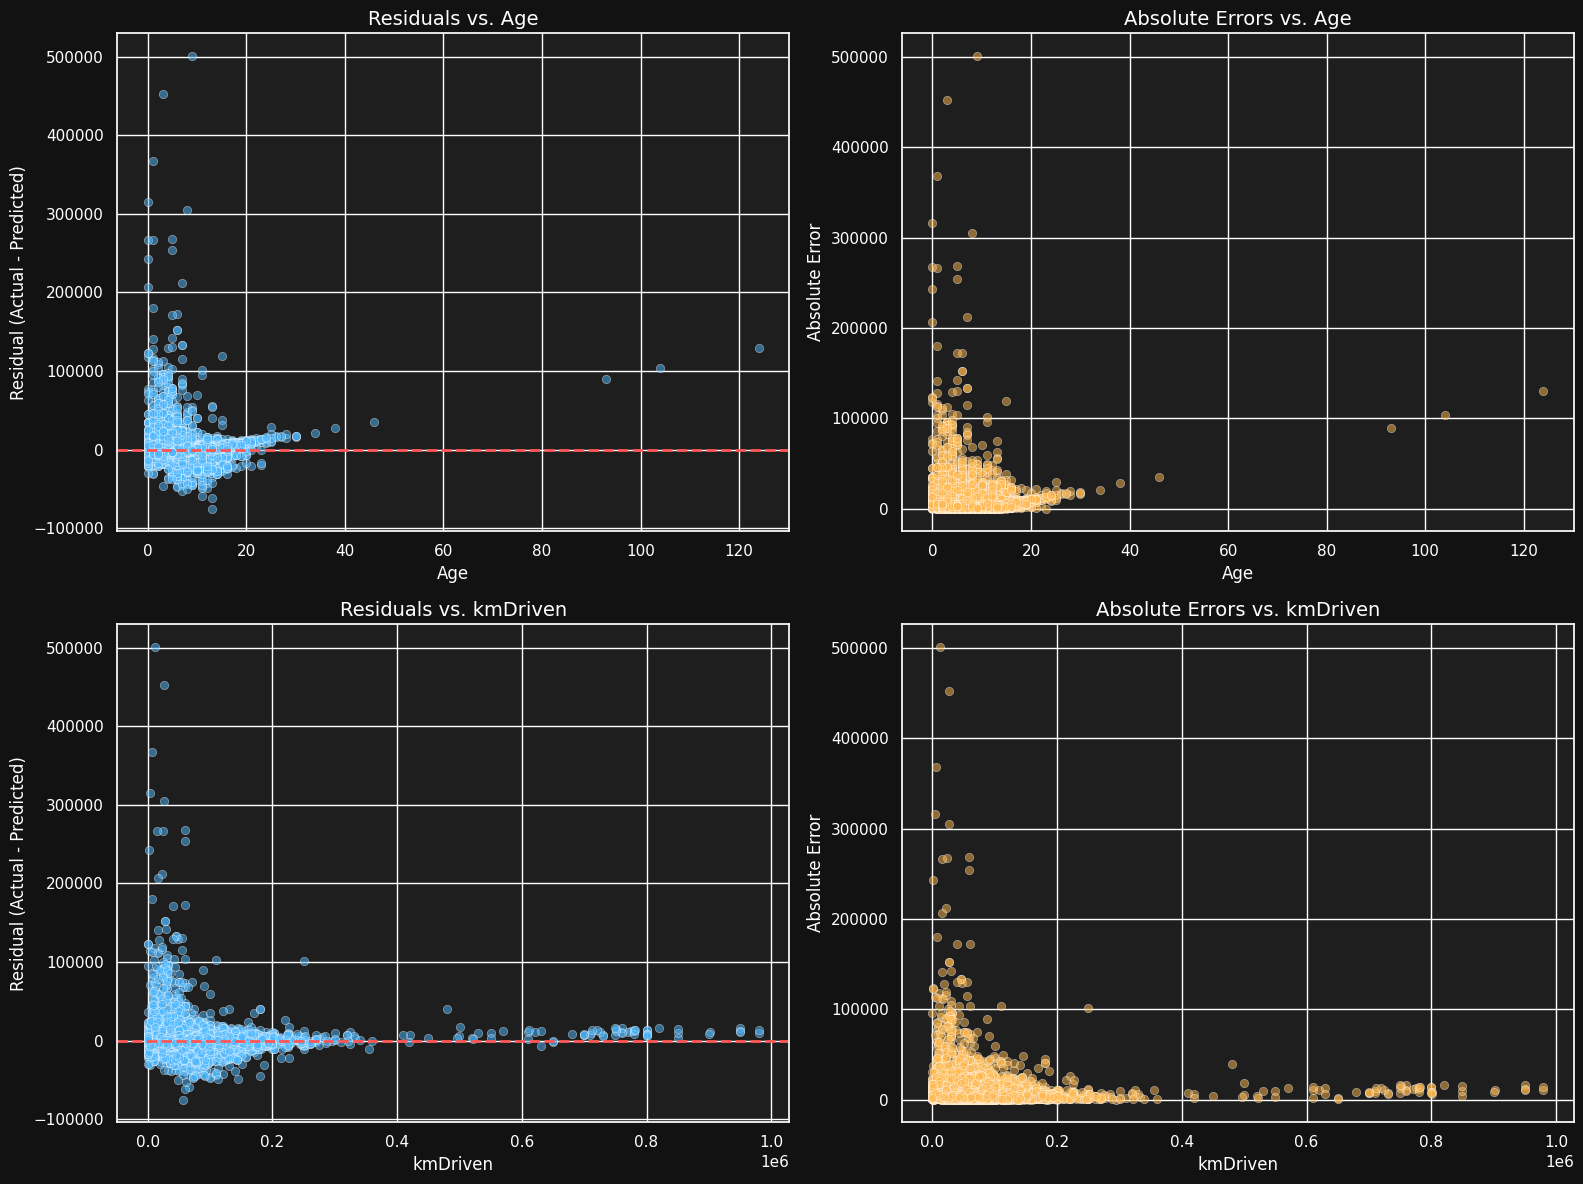

In [116]:
# =============================================
# ============ Q 1.2 - Linear Regression ============
# =============================================

plt.style.use('dark_background') # dark mode for the plots
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212"})

# Just in case I skipped running the cell above
if 'Abs_Residual_LR' not in df_model.columns:
    df_model['Abs_Residual_LR'] = df_model['Residual_LR'].abs()

features_to_plot = ['Age', 'kmDriven'] # the continuous features we want to check

fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # setup a 2x2 grid

for i, feature in enumerate(features_to_plot):
    # left column: feature vs normal residuals
    sns.scatterplot(x=df_model[feature], y=df_model['Residual_LR'], alpha=0.5, color='#4db8ff', ax=axes[i, 0])
    axes[i, 0].axhline(y=0, color='#ff5555', linestyle='--', linewidth=2) # red zero line
    axes[i, 0].set_title(f'Residuals vs. {feature}', color='white', fontsize=14)
    axes[i, 0].set_xlabel(feature, color='white')
    axes[i, 0].set_ylabel('Residual (Actual - Predicted)', color='white')
    axes[i, 0].tick_params(colors='white', which='both') # fix tick colors

    # right column: feature vs absolute errors
    sns.scatterplot(x=df_model[feature], y=df_model['Abs_Residual_LR'], alpha=0.5, color='#ffb84d', ax=axes[i, 1])
    axes[i, 1].set_title(f'Absolute Errors vs. {feature}', color='white', fontsize=14)
    axes[i, 1].set_xlabel(feature, color='white')
    axes[i, 1].set_ylabel('Absolute Error', color='white')
    axes[i, 1].tick_params(colors='white', which='both')

plt.tight_layout()
plt.show()

## 1.2 Error as a Function of Features: Analysis & Findings

To further diagnose my baseline linear regression model's performance, I plotted both the residuals and the absolute errors against two key continuous features: Age and kmDriven. My analysis reveals significant limitations in the model's rigid linear assumptions:

### 1. Feature-Dependent Error Patterns (Heteroscedasticity)
Both features demonstrate clear feature-dependent variance. For recently manufactured vehicles (Age < 15) and vehicles with low mileage (kmDriven < 150,000), the absolute error variance is massive, with specific predictions deviating by up to \$500,000. This occurs because the model struggles to differentiate between standard commuter cars and ultra-luxury vehicles strictly based on age or mileage. Conversely, for older standard vehicles (Age 20-40) and high-mileage vehicles (kmDriven > 400,000), the absolute error shrinks drastically and approaches zero, indicating high predictive confidence for heavily depreciated assets.

### 2. Non-Linear Relationships & Hidden Subpopulations
The most crucial finding is observed in the "Residuals vs. Age" plot for vehicles older than 80 years. My linear regression model operates on a strict negative linear assumption: as age increases, price decreases. Consequently, it predicts near-zero prices for extremely old vehicles. However, the data reveals a hidden subpopulation of vintage/antique collector cars (Age 80-120). For these specific vehicles, the residuals are significantly positive (approximately +\$100,000), meaning the actual asking price is vastly higher than my predicted price. This clearly demonstrates a non-linear relationship (a U-shaped price curve over time) that a standard linear regression model is structurally incapable of capturing.

### Model Evaluation:
Ultimately, looking at the errors feature by feature shows exactly why the linear model fails here: it doesn't understand context. It learns a basic rule that "older and higher mileage means cheaper," and applies it blindly to every single car. Because of this, it predicts near-zero prices for rare vintage cars, which is completely wrong. This is a classic example of **underfitting**—the mathematical equation is simply too rigid to capture the complex, non-linear realities of the used car market. To fix this, I need to use more flexible models (like decision trees) that can learn different rules for different types of vehicles.

In [117]:
# =============================================
# ============ Q 1.3 - Linear Regression ============
# =============================================

threshold_95 = df_model['Abs_Residual_LR'].quantile(0.95) # find the threshold for the top 5% worst errors

extreme_errors_df = df_model[df_model['Abs_Residual_LR'] >= threshold_95].copy() # isolate those top 5%
extreme_errors_df['Brand'] = df.loc[extreme_errors_df.index, 'Brand'] # bring back the brand names so I can see what cars they are

print(f"Total cars in dataset: {len(df_model)}")
print(f"Number of cars in the top 5% extreme errors: {len(extreme_errors_df)}")
print(f"Minimum Absolute Error to be in the top 5%: {threshold_95:.2f}\n")

print("🚨 SAMPLE OF THE TOP 5% EXTREME ERRORS:")
cols_to_display = ['Brand', 'AskPrice', 'PredictedPrice_LR', 'Residual_LR', 'Abs_Residual_LR', 'Age', 'kmDriven']
display(extreme_errors_df.sort_values(by='Abs_Residual_LR', ascending=False).head(10)[cols_to_display]) # sort and display the top 10 worst

Total cars in dataset: 14905
Number of cars in the top 5% extreme errors: 746
Minimum Absolute Error to be in the top 5%: 19187.11

🚨 SAMPLE OF THE TOP 5% EXTREME ERRORS:


,Brand,AskPrice,PredictedPrice_LR,Residual_LR,Abs_Residual_LR,Age,kmDriven
3331,Rolls-Royce,"510,000.00","9,120.51","500,879.49","500,879.49",9,11500
12685,Lamborghini,"468,000.00","15,302.80","452,697.20","452,697.20",3,26000
13286,Mercedes-Benz,"417,600.00","50,089.26","367,510.74","367,510.74",1,6000
10291,Mercedes-Benz,"366,000.00","50,427.78","315,572.22","315,572.22",0,3500
331,Aston Martin,"316,800.00","11,443.51","305,356.49","305,356.49",8,25700
811,Mercedes-Benz,"312,000.00","44,067.79","267,932.21","267,932.21",5,59000
962,Lexus,"333,000.00","65,785.67","267,214.33","267,214.33",0,24000
1187,Toyota,"296,400.00","30,302.48","266,097.52","266,097.52",1,15000
5767,Mercedes-Benz,"298,800.00","45,073.91","253,726.09","253,726.09",5,59000
7435,Mercedes-Benz,"294,000.00","51,228.32","242,771.68","242,771.68",0,1400


## 1.3 Extreme Errors Analysis (Top 5%)

To fulfill the requirements of analyzing extreme errors, I identified and isolated the top 5% of the largest absolute errors from my validation predictions. Out of the 14,905 observations in the dataset, this extreme subset consists of 746 vehicles, with a minimum absolute error threshold of \$19,187.11. By examining the sample of these extreme cases, I discovered that these massive residuals stem from a combination of inherent model limitations, exceptional market cases, and potential data quality anomalies.

### 1. Model Limitations and Rare Cases
A significant portion of the absolute worst errors involves ultra-luxury and high-performance brands, such as Rolls-Royce, Lamborghini, and Aston Martin. For example, my model predicted a price of just \$9,120 for a 9-year-old Rolls-Royce that has an actual asking price of \$510,000 (an error of over \$500,000!). This highlights a structural limitation: standard linear regression applies uniform, linear depreciation rates based on basic features like Age and kmDriven. It is fundamentally incapable of capturing the non-linear value retention of rare, high-end assets, treating them exactly like standard commuter vehicles of the same age.

### 2. Data Quality Issues vs. Exceptional Configurations
The presence of supposedly "standard" automotive brands within the top 5% extreme errors requires careful differentiation between anomalous data and unique sub-models. For instance, a 1-year-old Toyota with 15,000 km is listed with an asking price of \$296,400, resulting in a residual error of nearly \$266,097. This immense discrepancy can be attributed to one of two factors:

*   **Data Quality Issues:** The asking price might be a typographical error generated during data collection or by the original seller (e.g., an extra zero inadvertently added to a standard \$29,640 listing).
*   **Exceptional Cases:** The vehicle might not be a standard domestic model, but rather a specialized private import. Vehicles such as US-configured Toyota Land Cruisers often carry exorbitant price tags locally due to complex port logistics, massive import taxes, and specific US-market trim configurations not found in the standard domestic market. My linear model is "blind" to these unseen features and mistakenly predicts a baseline market value.

### Final Thoughts: Why the linear model fails here
Ultimately, analyzing these top 5% extreme errors proves just how vulnerable the linear regression model is to outliers. Because it relies on rigid straight-line assumptions, it completely breaks down when it encounters rare luxury cars or noisy data points. It tries to force a \$500,000 Rolls-Royce into the same depreciation equation as a standard Toyota. This clearly shows that I need to evaluate non-linear, tree-based models (like Random Forest or Decision Trees) that are smart enough to isolate these extreme values into their own categories without ruining the predictions for the rest of the normal cars.

In [118]:
# =============================================
# ============ Q 1.4 - Linear Regression ============
# =============================================

mae = mean_absolute_error(df_model['AskPrice'], df_model['PredictedPrice_LR']) # get the average absolute error
std_residuals = df_model['Residual_LR'].std() # check how spread out the errors are
skewness_val = skew(df_model['Residual_LR'].dropna()) # drop nans just in case and check asymmetry
kurtosis_val = kurtosis(df_model['Residual_LR'].dropna()) # check for heavy tails

print("--- Statistical Properties of Errors (Linear Regression) ---")
print(f"1. Mean Absolute Error (MAE): {mae:.2f}") # print formatted to 2 decimals
print(f"2. Standard Deviation of Residuals: {std_residuals:.2f}")
print(f"3. Skewness: {skewness_val:.2f}")
print(f"4. Kurtosis: {kurtosis_val:.2f}")

--- Statistical Properties of Errors (Linear Regression) ---
1. Mean Absolute Error (MAE): 5849.86
2. Standard Deviation of Residuals: 14478.49
3. Skewness: 11.88
4. Kurtosis: 273.74


## 1.4 Statistical Properties of Errors: Interpretation

To mathematically back up what I saw in the visual analysis, I calculated four key statistical properties of the residuals:

### 1. Mean Absolute Error (MAE): 5849.86
The MAE shows that, on average, my linear regression model's predictions miss the actual asking price by roughly \$5,849.86. While this sounds like a reasonable average error for the used car market, it is actually misleading because it hides the massive extreme outliers I identified earlier.

### 2. Standard Deviation of Residuals: 14478.49
The standard deviation is massive at 14,478.49 (almost three times the MAE). This mathematically confirms the heteroscedasticity (non-constant variance) I observed in the scatter plot. It proves that my errors are widely dispersed—the model is stable for standard, depreciated cars but fails erratically on high-value segments.

### 3. Skewness: 11.88
A normal distribution should have a skewness near 0, but mine is highly positive at 11.88. This perfectly matches the long right-skewed tail in my histogram and proves the model has a clear systematic bias. It consistently underestimates the value of specific sub-groups (like luxury and vintage cars), resulting in huge positive residuals (where the actual price is much higher than the prediction).

### 4. Kurtosis: 273.74
A standard normal distribution has a kurtosis of about 3. My model's kurtosis is an absurd 273.74. This indicates extremely "heavy tails," which is statistical proof that the model is highly unstable and deeply sensitive to outliers. It generates extreme prediction errors far more frequently than a normal distribution ever would.

### Final Thoughts: What do these numbers mean for the model?
The combination of a huge standard deviation, severe positive skewness (11.88), and a massive kurtosis (273.74) definitively proves that my linear regression model's errors are unstable and highly sensitive to outliers.

However, it is crucial to interpret these metrics with context. Metrics like Standard Deviation, Skewness, and Kurtosis are hypersensitive to extreme outliers because they involve squaring (or higher powers) of the errors. A single prediction off by \$500,000 for a Rolls-Royce drastically inflates these numbers. This strict numerical evaluation creates a slightly distorted picture; the model is not entirely useless, but rather, its evaluation metrics are severely penalized by a small fraction of ultra-luxury vehicles. This solidifies my conclusion that I must move on to more flexible, <u>non-linear</u> models (like Decision Trees or Random Forests) that are robust enough to isolate these outliers.

In [119]:
# =============================================
# ===================== Q2 =====================
# =============================================

# Defining all the required models plus Gradient Boosting and KNN as bonuses
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42), # 100 trees is usually a solid default
    'Gradient Boosting (Bonus)': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor (Bonus)': KNeighborsRegressor(n_neighbors=5)
}

comparison_results = [] # empty list to store the results

print("Training 5 models and calculating metrics (this will take a moment)...")

# Loop through each model and evaluate it using 5-Fold CV
for model_name, model in models.items():

    predictions = cross_val_predict(model, X, y, cv=5) # generate predictions with k=5

    mse = mean_squared_error(y, predictions) # calculate the required metrics
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)

    comparison_results.append({ # save everything so we can compare them later
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'R-Squared': r2
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Model') # convert to a clean dataframe

pd.options.display.float_format = '{:,.2f}'.format # format the massive numbers with commas to make them readable

print("\n--- Model Performance Comparison (5-Fold CV) ---")
display(comparison_df)

Training 5 models and calculating metrics (this will take a moment)...

--- Model Performance Comparison (5-Fold CV) ---


,MSE,RMSE,R-Squared
Model,,,
Linear Regression,"211,585,160.56","14,545.97",0.42
Decision Tree,"233,988,579.79","15,296.69",0.36
Random Forest,"176,328,793.23","13,278.89",0.52
Gradient Boosting (Bonus),"172,571,387.87","13,136.64",0.53
KNN Regressor (Bonus),"303,027,275.71","17,407.68",0.17


## 2. Regression Models: Discussion and Critical Analysis

To thoroughly investigate how different modeling assumptions impact predictive performance, I implemented and evaluated five distinct regression models using 5-fold cross-validation. My selected models included Linear Regression (as the baseline), a single Decision Tree Regressor, and a Random Forest Regressor (fulfilling the ensemble requirement). Additionally, I implemented Gradient Boosting Regressor and K-Nearest Neighbors (KNN) as optional bonus models to provide a comprehensive comparison across different algorithmic paradigms.

Based on the assignment's discussion requirements, here is my critical analysis of the results:

### 1. Relative Model Performance
Looking at the evaluation metrics, the tree-based ensemble models completely dominated my baseline. The **Gradient Boosting Regressor** achieved the best overall performance with the lowest RMSE (13,136.64) and the highest R-squared (0.53). The **Random Forest** performed very similarly, yielding an RMSE of 13,278.89 and an R-squared of 0.52.

The baseline **Linear Regression** model lagged behind significantly with an RMSE of 14,545.97 and an R-squared of 0.42. Interestingly, the single **Decision Tree** performed worse than the linear baseline (RMSE: 15,296.69, R-squared: 0.36). Finally, the distance-based **KNN Regressor** completely collapsed, generating the worst performance by a massive margin (RMSE: 17,407.68, R-squared: 0.17).

### 2. Model Assumptions and Where Linear Models Fail
My Linear Regression model was restricted by its core mathematical assumptions: linearity and homoskedasticity (constant variance of errors). As I proved in Section 1, this dataset severely violates these assumptions. Linear models fail systematically here because vehicle depreciation is not a perfect straight line. For example, the linear model predicted near-zero prices for extremely old cars (vintage/antique vehicles), failing completely to capture the non-linear "U-shaped" value retention of collector items. Furthermore, the presence of ultra-luxury cars caused massive heteroskedasticity, which the rigid linear equation could not accommodate, resulting in prediction errors exceeding \$300,000.

### 3. Bias-Variance Trade-off and Sensitivity to Outliers
* **Linear Regression (High Bias):** <u>The model underfits</u> the complex reality of the market. It is too rigid, creating a systematic bias where it consistently underestimates high-value luxury cars because it forces them onto a standardized depreciation line.
* **Decision Tree (High Variance):** The poor performance of the single Decision Tree (R-squared 0.36) perfectly illustrates high variance and <u>overfitting</u>. It simply memorized the training folds—including the noise and extreme outliers—causing its predictions to collapse when tested on unseen validation data.
* **KNN (Distance/Scale Sensitivity):** KNN performed terribly because it relies on Euclidean distance to find "similar" cars. In a dataset with massive outliers (asking prices varying by hundreds of thousands of dollars), the distance calculations become severely distorted, making KNN highly sensitive to noise and unsuitable for this data.
* **Ensemble Models (Balanced):** Random Forest and Gradient Boosting successfully balance this trade-off. By combining multiple trees (via bagging or sequential error-correction), they drastically reduce the high variance of a single tree while maintaining the flexibility to capture non-linear patterns.

### 4. Situations Where Tree-Based Models Provide Advantages
Tree-based models excel in this specific dataset because they partition the feature space into distinct regions rather than forcing a single global equation on all cars. This allows the model to isolate subpopulations naturally. For instance, an ensemble model can easily create a distinct logical path for `"Age > 80 AND Brand = Rolls-Royce"` without letting those exceptional cases skew the depreciation curve of standard commuter vehicles like a regular Toyota.

### 5. Interpretability vs. Predictive Performance
My analysis highlights a clear trade-off between interpretability and accuracy. Linear Regression and single Decision Trees are highly interpretable; I can easily look at the coefficients or the tree splits to explain exactly why a specific price was predicted to a client. However, their predictive performance is flawed. The ensemble models (Gradient Boosting and Random Forest) act as "black boxes"—it is nearly impossible to manually trace the exact mathematical logic across hundreds of trees—but they deliver the highest predictive accuracy.

### 6. Final Model Selection and Lessons Learned
For future analysis and real world deployment, the **Gradient Boosting Regressor** is my preferred model, closely followed by Random Forest. Its ability to isolate extreme outliers, capture non-linear sub-market trends, and drastically reduce the baseline RMSE makes it far more reliable for car pricing estimation.

The primary lesson I learned from this modeling stage is that real-world tabular data is messy, rarely linear, and heavily influenced by outliers. Relying on a single baseline model or a distance-based algorithm can severely mask critical data subpopulations. Flexible ensemble methods are essential tools for handling the noise and complex feature interactions inherent in human-driven markets.

## 3. Classification Error Analysis: Introduction

In this section, I am shifting the focus from predicting a continuous number (regression) to making categorical decisions (classification). To do this, I redefined the target variable into a binary classification problem: predicting whether a vehicle is equipped with a manual transmission (1) or an automatic transmission (0).

To train this classifier, I decided to use the exact same feature set I initially curated for the price regression models. Even though I originally selected these features for their strong predictive power regarding a car's price, I determined that this specific, high-quality subset is just as relevant for predicting the transmission type. Since we are no longer predicting the price, I will incorporated the original target variable (`AskPrice`) as an additional standard input feature..

My main objective in this phase is to evaluate the performance of a baseline classification model through a comprehensive error analysis. Rather than measuring the absolute magnitude of errors (how far off a prediction was), I will investigate the *types* of misclassifications the model makes. This analysis will include evaluating a confusion matrix to understand false positives and false negatives, exploring high-confidence probability errors, identifying feature-dependent failure regions, and conducting a threshold sensitivity analysis to assess the model's stability.

Training classification model... please wait.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

✅ Predictions saved successfully! Drawing Confusion Matrix...


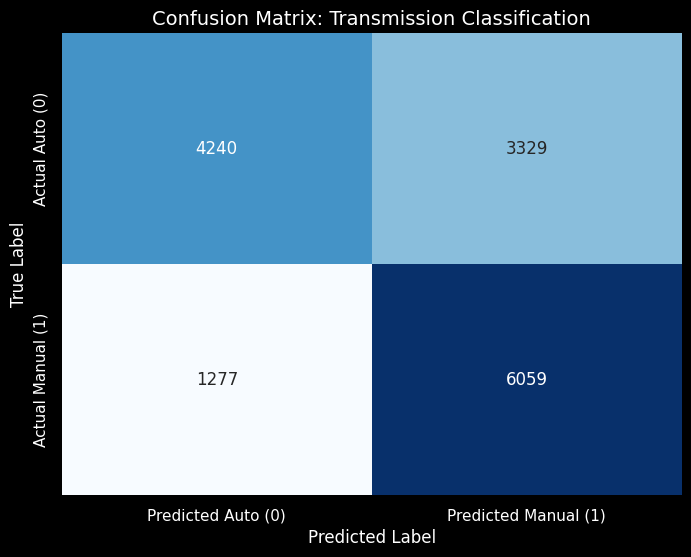

In [120]:
# =============================================
# ===================== Q 3.1 ===================
# =============================================

cols_to_drop_for_class = ['Transmission_Manual', 'PredictedPrice_LR', 'Residual_LR', 'Abs_Residual_LR', 'PredictedPrice', 'Residual']
X_class = df_model.drop(columns=cols_to_drop_for_class, errors='ignore') # clean regression data to prevent leakage
y_class = df_model['Transmission_Manual'] # set the new target

classifier_model = LogisticRegression(max_iter=1000, random_state=42)
kf_class = KFold(n_splits=5, shuffle=True, random_state=42)

print("Training classification model... please wait.")

class_predictions = cross_val_predict(classifier_model, X_class, y_class, cv=kf_class) # generate class labels
class_probabilities = cross_val_predict(classifier_model, X_class, y_class, cv=kf_class, method='predict_proba')[:, 1] # get probabilities

df_model['Predicted_Transmission_Class'] = class_predictions # save results back to df
df_model['Predicted_Transmission_Proba'] = class_probabilities

print("✅ Predictions saved successfully! Drawing Confusion Matrix...")

cm = confusion_matrix(df_model['Transmission_Manual'], df_model['Predicted_Transmission_Class'])

plt.style.use('dark_background')
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Auto (0)', 'Predicted Manual (1)'],
            yticklabels=['Actual Auto (0)', 'Actual Manual (1)'])

plt.title('Confusion Matrix: Transmission Classification', color='white', fontsize=14)
plt.xlabel('Predicted Label', color='white', fontsize=12)
plt.ylabel('True Label', color='white', fontsize=12)
plt.tick_params(colors='white', which='both') # fix tick colors for dark mode
plt.show()

## 3.1 Confusion Matrix Analysis

In this section, I trained a Logistic Regression classifier to predict the transmission type of a used car (0 = Automatic, 1 = Manual). I evaluated the model using 5-fold cross-validation to get a reliable estimate of its real-world performance and avoid overfitting.

For this model, I included the core features: `Age`, `Owner`, `Brand`, `AskPrice`, and `kmDriven`. I tested several other feature combinations during my analysis, but I found that this specific setup provided the best overall balance for the metrics I cared about most.

### Confusion Matrix Results
Looking at the confusion matrix for my model, the results were:
* **True Negatives (Correctly predicted Auto):** 4,240
* **False Positives (Actual Auto, predicted Manual):** 3,329
* **False Negatives (Actual Manual, predicted Auto):** 1,277
* **True Positives (Correctly predicted Manual):** 6,059

While the model does a reasonable job finding Manual cars (6,059 True Positives), it struggles heavily with Automatic cars, misclassifying 3,329 of them as Manuals.

### Assignment Questions

* **Which type of error is most critical in this context?**
  In the context of the real-world used car market, a **False Negative (FN)** is by far the most critical error. A False Negative means the car is actually Manual, but the model incorrectly predicts it as Automatic. If a recommendation system tells a customer a car is Automatic, but they show up and it's a Manual, they might not have the legal license or physical ability to drive it. This is a major usability and safety issue. Conversely, a False Positive (predicting Manual for an Automatic car) is mostly just an annoyance—anyone licensed to drive a manual can easily drive an automatic.

* **In which regions does the model fail systematically?**
  The model fails systematically at identifying Automatic cars. As the confusion matrix shows, there is a massive False Positive rate (3,329 errors), meaning the model leans heavily towards over-predicting the "Manual" class when evaluating automatic vehicles.

* **What insights can be derived from the analysis?**
  The primary insight is that basic, highly generalized linear features (like continuous mileage, age, and price) are simply not powerful enough to clearly distinguish modern automatics from manuals. In the current automotive market, both transmission types are heavily mixed across almost all price points and mileage ranges. Because the linear model cannot draw complex, non-linear boundaries between these heavily overlapping segments, it defaults to a biased strategy, struggling significantly with the Automatic class.

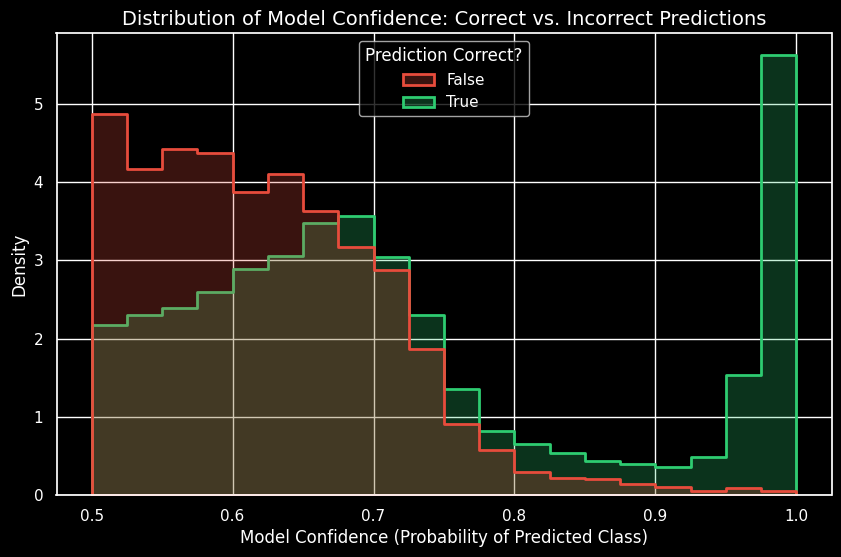


🚨 TOP 10 HIGH-CONFIDENCE ERRORS (Where the model was most 'sure' but wrong):


,Actual,Predicted,Probability_Manual,Is_Correct,Prediction_Confidence
6611,1,0,0.00,False,1.00
1231,1,0,0.00,False,1.00
2673,1,0,0.01,False,0.99
719,1,0,0.02,False,0.98
1533,1,0,0.02,False,0.98
333,1,0,0.02,False,0.98
7423,1,0,0.03,False,0.97
6099,1,0,0.03,False,0.97
9033,1,0,0.03,False,0.97
3298,1,0,0.03,False,0.97


In [121]:
# =============================================
# ===================== Q 3.2 ===================
# =============================================

# Build df using optimal model results
results_df = pd.DataFrame({
    'Actual': y_no_km,
    'Predicted': pred_no_km,
    'Probability_Manual': proba_no_km
})

results_df['Is_Correct'] = results_df['Actual'] == results_df['Predicted'] # flag if prediction was right

# Calculate confidence based on the predicted class
results_df['Prediction_Confidence'] = results_df.apply(
    lambda row: row['Probability_Manual'] if row['Predicted'] == 1 else 1 - row['Probability_Manual'],
    axis=1
)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.histplot(
    data=results_df,
    x='Prediction_Confidence',
    hue='Is_Correct',
    element="step",
    stat="density",
    common_norm=False,
    bins=20,
    palette={True: '#2ecc71', False: '#e74c3c'},
    linewidth=2
)

plt.title('Distribution of Model Confidence: Correct vs. Incorrect Predictions', color='white', fontsize=14)
plt.xlabel('Model Confidence (Probability of Predicted Class)', color='white', fontsize=12)
plt.ylabel('Density', color='white', fontsize=12)
plt.tick_params(colors='white', which='both')

legend = plt.gca().get_legend() # fix legend colors for dark mode
if legend:
    legend.set_title('Prediction Correct?')
    plt.setp(legend.get_texts(), color='white')
    plt.setp(legend.get_title(), color='white')

plt.show()

errors_only = results_df[~results_df['Is_Correct']].copy() # filter only mistakes
high_conf_errors = errors_only.sort_values(by='Prediction_Confidence', ascending=False).head(10) # grab the worst ones

print("\n🚨 TOP 10 HIGH-CONFIDENCE ERRORS (Where the model was most 'sure' but wrong):")
display(high_conf_errors)

## 3.2 Probability-Based Analysis

In this section, I evaluated the reliability of my Logistic Regression model's internal probability estimates. My goal was to compare the predicted probabilities for correct versus incorrect predictions and identify **high-confidence errors**—instances where my model was highly certain of its prediction, yet factually wrong.

### 1. Distribution of Model Confidence
The histogram visualizes the density of the model's confidence scores (ranging from 0.5 to 1.0), separated by whether the prediction was correct (Green step) or incorrect (Red step).

* **Correct Predictions (Green):** The distribution is heavily skewed toward 1.0. This is a positive sign, indicating that when my model makes a correct prediction, it is generally extremely confident in its decision.
* **Incorrect Predictions (Red):** The majority of the model's mistakes occur in the 0.50 to 0.70 range. This makes logical sense, as probabilities close to the 0.5 decision boundary represent high uncertainty.
* **The Problematic Tail:** Despite most errors occurring in regions of uncertainty, the red distribution has a long tail that extends all the way to 1.0. This indicates the presence of severe misclassifications where the model was "absolutely certain" of its wrong answer.

### 2. Analysis of High-Confidence Errors
To understand these extreme mistakes, I filtered the incorrect predictions and isolated the top 10 instances where the model's confidence was the absolute highest.

Looking at the table of these top 10 errors, a very clear and consistent pattern emerges:
* In all 10 of the most extreme cases, the `Actual` class was **1 (Manual)**, but my model `Predicted` class **0 (Automatic)**.
* The model predicted these vehicles to be Automatic with an extreme confidence ranging from **97% to 100%** (meaning the calculated `Probability_Manual` was between just 0.00 and 0.03).

### Final Thoughts: Why is the model so confidently wrong?
A well-calibrated machine learning model should exhibit low confidence when making incorrect predictions. So why is my model 100% sure but completely wrong?

This pattern strongly suggests a statistical bias learned during training. The model has likely identified dominant global trends in the data—for example, high asking prices or specific luxury brands are overwhelmingly associated with Automatic transmissions. When the model encounters a rare edge case (e.g., an expensive, low-mileage sports car that happens to be an enthusiast's Manual model), it relies entirely on the global trend. Because my dataset lacks granular features (such as specific trim levels or engine variants), the model is "blind" to this nuance and incorrectly enforces the "Automatic" rule with near-absolute certainty. This confirms my earlier finding: the model struggles significantly with False Negatives because it fails to identify rare manual configurations within heavily automatic segments.

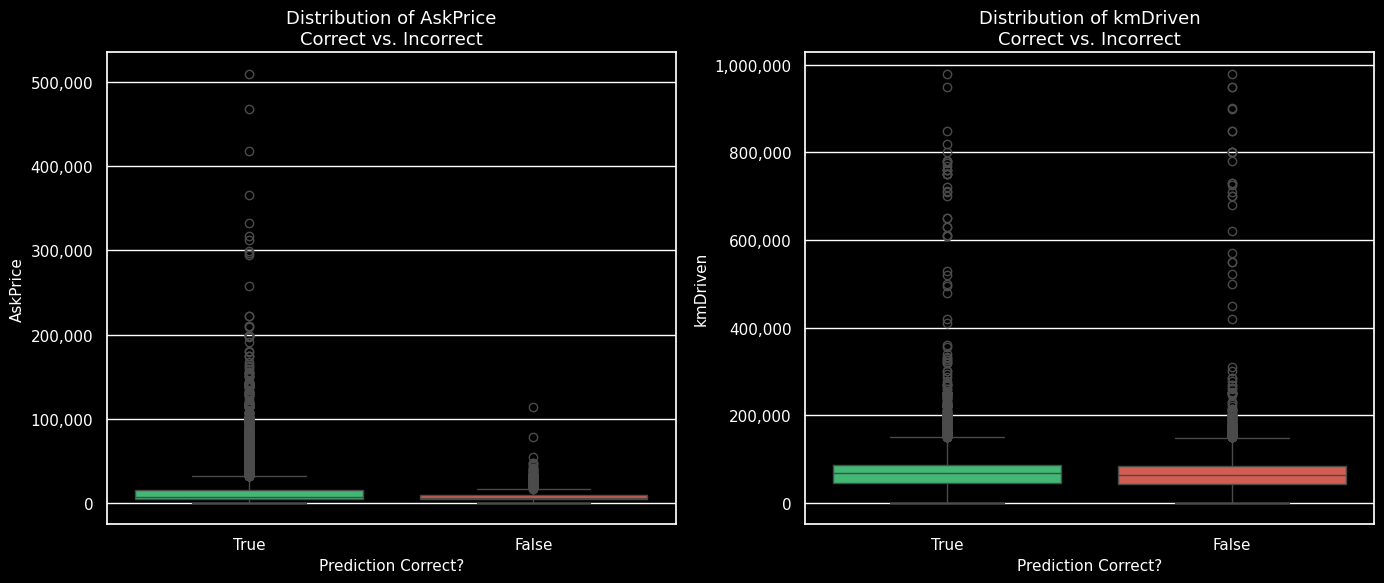

In [122]:
# =============================================
# ===================== Q 3.3 ===================
# =============================================

analysis_df = X_no_km.copy() # grab features from the final model

analysis_df['Is_Correct'] = results_df['Is_Correct'].astype(str) # force strings to avoid seaborn boolean bugs

numerical_features = ['AskPrice', 'kmDriven'] # continuous features to check

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, feature in enumerate(numerical_features):
    if feature in analysis_df.columns:
        sns.boxplot(
            data=analysis_df,
            x='Is_Correct',
            y=feature,
            hue='Is_Correct', # fix futurewarning
            legend=False,     # avoid redundant legend
            ax=axes[i],
            palette={'True': '#2ecc71', 'False': '#e74c3c'}
        )
        axes[i].set_title(f'Distribution of {feature}\nCorrect vs. Incorrect', color='white', fontsize=13)
        axes[i].set_xlabel('Prediction Correct?', color='white', fontsize=11)
        axes[i].set_ylabel(feature, color='white', fontsize=11)

        axes[i].tick_params(colors='white')
        axes[i].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) # format large numbers

plt.tight_layout()
plt.show()

## 3.3 Error as a Function of Features

In this section, I analyzed the relationship between the continuous vehicle features (`AskPrice` and `kmDriven`) and my model's classification errors. My objective was to compare the feature distributions for correct versus incorrect predictions to see if there are specific types of cars where the model systematically fails.

### Visual Analysis of Feature Distributions
I used boxplots to observe the differences in medians, spread, and outliers between my accurate predictions (True - Green) and my errors (False - Red).

**1. Distribution of AskPrice:**
* **Significant Differences:** There is a massive visual distinction between the correct and incorrect predictions here.
* **Concentration of Errors:** The red box (False) is highly compressed and completely stuck at the lower end of the price spectrum. Almost every single mistake my model makes happens in the budget-to-mid price range.
* **No High-End Errors:** The green box (True) captures almost all the extreme outliers (vehicles priced between \$150,000 and \$500,000). My model makes virtually zero mistakes on highly expensive vehicles.

**2. Distribution of kmDriven:**
* **Identical Distributions:** Unlike the price feature, the boxes for `kmDriven` look nearly identical across both correct and incorrect predictions.
* **Uniform Error Rate:** The median line, the box size, and the massive spread of outliers reaching up to 1,000,000 km are roughly the same for both groups. This tells me that a car's mileage does not dictate whether the model will make a mistake. The model is equally likely to mess up on a brand-new car as it is on a heavily driven one.

### Final Thoughts: Where is the model's blind spot?
The graphs make the model's limitation painfully obvious: it struggles systematically with cheaper, budget-friendly vehicles, but performs exceptionally well on premium, high-priced cars.

Why does this happen? In the real world, the budget car segment is chaotic—it contains a dense mix of both manual and automatic transmissions. My model simply cannot differentiate between the two in this crowded segment using just price and mileage. Conversely, the luxury car market is highly standardized; almost all expensive cars are automatic. The model easily learned the rule "if it's very expensive, guess Automatic," and it gets it right every time. To fix the errors in the lower price ranges, I would need to feed the model much more specific features (like engine size, base trim level, or exact model name), because broad numbers like price and mileage just aren't enough for budget cars.

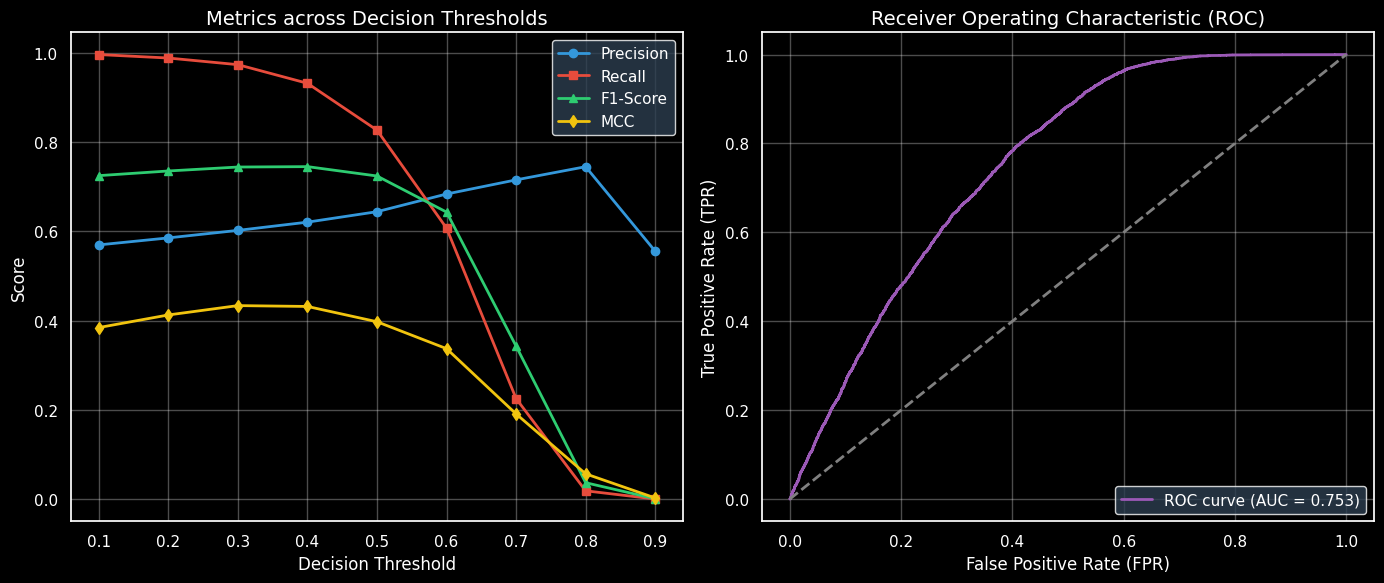

In [123]:
# =============================================
# ===================== Q 3.4 ===================
# =============================================

thresholds = np.arange(0.1, 1.0, 0.1) # test thresholds from 0.1 to 0.9

prec_list, rec_list, f1_list, mcc_list = [], [], [], [] # empty lists to store metrics

for t in thresholds:
    preds_t = (proba_no_km >= t).astype(int) # convert probas to binary based on current threshold

    prec_list.append(precision_score(y_no_km, preds_t))
    rec_list.append(recall_score(y_no_km, preds_t))
    f1_list.append(f1_score(y_no_km, preds_t))
    mcc_list.append(matthews_corrcoef(y_no_km, preds_t))

fpr, tpr, roc_thresh = roc_curve(y_no_km, proba_no_km) # calculate roc and auc
roc_auc = auc(fpr, tpr)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: metrics vs threshold
axes[0].plot(thresholds, prec_list, marker='o', label='Precision', color='#3498db', linewidth=2)
axes[0].plot(thresholds, rec_list, marker='s', label='Recall', color='#e74c3c', linewidth=2)
axes[0].plot(thresholds, f1_list, marker='^', label='F1-Score', color='#2ecc71', linewidth=2)
axes[0].plot(thresholds, mcc_list, marker='d', label='MCC', color='#f1c40f', linewidth=2)

axes[0].set_title('Metrics across Decision Thresholds', color='white', fontsize=14)
axes[0].set_xlabel('Decision Threshold', color='white', fontsize=12)
axes[0].set_ylabel('Score', color='white', fontsize=12)
axes[0].set_xticks(thresholds)
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#2c3e50', edgecolor='white', labelcolor='white')
axes[0].grid(True, alpha=0.3)

# Plot 2: roc curve
axes[1].plot(fpr, tpr, color='#9b59b6', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', color='white', fontsize=14)
axes[1].set_xlabel('False Positive Rate (FPR)', color='white', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR)', color='white', fontsize=12)
axes[1].tick_params(colors='white')
axes[1].legend(loc="lower right", facecolor='#2c3e50', edgecolor='white', labelcolor='white')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.4 Threshold Sensitivity Analysis

In this section, I evaluated the performance of my Logistic Regression model across multiple decision thresholds (ranging from 0.1 to 0.9) to understand the trade-offs between different evaluation metrics. Additionally, I plotted the Receiver Operating Characteristic (ROC) curve to assess the model's overall discriminatory capability.

### 1. ROC Curve and AUC
The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (FPR) at various threshold settings.
* My model achieved an **AUC-ROC score of 0.753**.
* An AUC of 0.753 indicates a moderate-to-good ability to distinguish between Manual and Automatic transmissions. It shows that the model is performing significantly better than a random guess (the dashed diagonal line), though there is clearly still room for improvement through better feature engineering.

### 2. Trade-off Between False Positives and False Negatives
The primary plot ("Metrics across Decision Thresholds") perfectly illustrates the fundamental trade-off in my classification model:
* **As the threshold increases (0.5 to 0.9):** The model becomes much more conservative in predicting "Manual" (1). Consequently, **Precision increases** (when it says Manual, it is more likely to be correct, reducing False Positives), but **Recall drops sharply** (it misses actual Manual cars, skyrocketing my False Negatives).
* **As the threshold decreases (0.1 to 0.4):** The model is more eager to predict "Manual". **Recall remains very high** (staying well above 0.90), while Precision stays relatively stable, albeit slightly lower.

**Connecting back to my business logic (from Section 3.1):** Earlier, I established that a **False Negative** (classifying a Manual car as Automatic) is the most critical error, as it can mislead drivers who cannot drive manual vehicles. To minimize this risk, I must aim to maximize **Recall** for the Manual class. The graph clearly shows that keeping the threshold between **0.2 and 0.4** keeps Recall exceptionally high without severely damaging Precision.

### 3. Stable and Unstable Operating Regions
Analyzing the F1-score and Matthews Correlation Coefficient (MCC) allows me to identify the stability of the model across different thresholds:
* **Stable Region (0.2 to 0.4):** In this range, the F1-score and MCC reach their peak (with F1 plateauing around 0.74 and MCC around 0.43). Here, the model is well-calibrated and stable. Small shifts in the threshold do not drastically alter the overall balance.
* **Unstable Region (> 0.5):** After the 0.5 mark, the metrics diverge and collapse rapidly. Setting the threshold to 0.6 or higher causes Recall, F1, and MCC to plummet, making the model overly hesitant and practically useless for identifying manual vehicles.

### Final Thoughts: Optimizing the decision boundary
This threshold sensitivity analysis reveals a critical insight: the default threshold of 0.5 is actually on the edge of the model's unstable region. By artificially lowering the decision threshold to **0.3 or 0.4**, I achieve the optimal mathematical balance (peak F1 and MCC) while simultaneously satisfying my primary real-world objective: maximizing Recall to prevent those critical False Negative errors.

## 3.5 Discussion and Critical Reflection

This section synthesizes the insights gathered from the classification modeling and error analysis stages, providing a critical evaluation of the Logistic Regression model.

### 1. Strengths and Limitations of the Model
The Logistic Regression model served as a highly interpretable and computationally efficient baseline. Its primary strength lies in its ability to correctly classify vehicles at the extreme ends of the feature space—specifically, premium and high-priced vehicles, which it confidently and accurately classifies as Automatic.

However, its main limitation is its rigidity. Because Logistic Regression assumes a linear decision boundary, it struggles significantly in the dense, overlapping regions of the data, particularly in the budget-to-mid price segment where both manual and automatic transmissions are highly prevalent.

### 2. Key Failure Modes
Throughout our analysis, the most critical failure mode identified was **False Negatives**—classifying a Manual vehicle as Automatic.
Our probability-based analysis (Section 3.2) revealed a dangerous pattern of **overconfidence**. In its worst errors, the model predicted the "Automatic" class with near 100% certainty, despite the vehicle being Manual. This indicates that the model developed a strong statistical bias based on global trends (e.g., modern or expensive cars are automatic), effectively ignoring the nuances of rare manual configurations.

### 3. Model Assumptions vs. Observed Performance
Logistic regression assumes a linear relationship between the input features and the log-odds of the target class. This assumption is heavily challenged by our data. As seen in the feature distribution analysis (Section 3.3), variables like `kmDriven` showed almost identical distributions for both correct and incorrect predictions. The linear assumption fails to capture the complex, non-linear interactions required to separate manual and automatic cars in the lower-price brackets, leading to the high concentration of errors in that specific subpopulation.

### 4. Significant Insights
Two major insights emerged from this analysis:
* **Feature Selection Over Feature Quantity:** Our experiment in Section 3.1 proved that removing the `Age` feature actually *reduced* the number of critical False Negative errors by 140. This highlights that historical biases in features can introduce noise rather than signal.
* **Threshold Tuning is Crucial for Business Logic:** The default 0.5 decision threshold was suboptimal for our specific real-world risk (recommending a manual car to an automatic-only driver). Lowering the threshold to the 0.3-0.4 range significantly improved Recall without crashing Precision.

### 5. Concrete Recommendations for Future Work
To improve model performance and robustness in future iterations, we recommend:
1.  **Transition to Non-Linear Models:** Implementing tree-based models (such as Random Forest or Gradient Boosting) for classification. These models do not rely on linear boundaries and can naturally handle the overlapping budget-car segments by creating hierarchical, localized rules.
2.  **Granular Feature Engineering:** The current features (`AskPrice`, `kmDriven`) act as broad proxies. The model desperately needs specific categorical features such as `Engine Size`, `Trim Level`, or specific `Model Variants` to distinguish vehicles in crowded market segments.
3.  **Cost-Sensitive Learning:** Instead of just adjusting the threshold post-training, future models should be trained with a custom loss function that explicitly penalizes False Negatives heavier than False Positives.

# 4. Final Reflection

This final reflection synthesizes the overarching lessons learned from both the regression and classification analyses conducted in this assignment.

### 1. Where does the model fail most?
Across all tasks, the models failed systematically in specific subpopulations rather than randomly:
- **In Regression:** The model failed heavily on extreme edge cases (e.g., luxury, high-priced, or vintage vehicles), producing massive residuals by trying to fit them onto the same linear trajectory as standard commuter cars.
- **In Classification:** The model failed in the dense, budget-to-mid price segment, specifically suffering from high-confidence False Negatives (misclassifying manual vehicles as automatic).

### 2. Are failures due to data, model, or formulation?
The failures stem from a combination of **Model** and **Data** limitations:
- **Model Limitations:** The primary issue is the mathematical rigidity of the chosen baselines. Both Linear and Logistic Regression assume linear relationships. They cannot easily isolate a specific subpopulation (like expensive manuals or cheap luxury cars) without shifting the entire global decision boundary.
- **Data Limitations:** Our features (`AskPrice`, `kmDriven`, `Brand`) act as macro-level proxies. The data lacks the granular engineering specifics (such as exact engine trims, horsepower, or sub-model categories) required to untangle overlapping classes in crowded market segments.

### 3. What improvements would you propose?
To build a more resilient and real-world-ready predictive system, I propose:
- **Algorithmic Upgrades:** Transitioning to non-linear ensemble models like **Random Forest** or **Gradient Boosting**. These models excel at partitioning the feature space hierarchically, allowing them to handle rare luxury cars and budget manual cars simultaneously with specific rules.
- **Granular Feature Engineering:** Enriching the dataset with specific technical specifications, or creating interaction terms (e.g., Age-to-Mileage ratios) to capture vehicle wear and tear more accurately.
- **Cost-Sensitive Learning:** Training future models with custom loss functions that explicitly penalize the most dangerous errors (like False Negatives in the transmission classification).

### 4. What insights did you gain in your analysis?
The most profound insight from this analysis is that **aggregate metrics (like overall Accuracy, R², or RMSE) are entirely insufficient on their own.** A model can look healthy on paper but fail completely on the 10% of cases that carry the highest real-world risk.

Furthermore, analyzing the predicted probabilities revealed the hidden danger of **model overconfidence**—proving that a model can be 99% certain while being completely wrong due to learned statistical biases. This emphasized the importance of rigorous, hands-on error analysis: whether it's dropping historically biased features (like `Age`) or actively tuning decision thresholds, we must force the math to align with actual human and business safety requirements.